
# Synoppsis

1. A python script to implement a multi-classifier model based on  DecisionTreeClassifier algorithm 
using supervised learning.

2. A decision tree classifier algorithm is used to predict species of following flowers:
                   - Setosa
                   - Versicolor
                   - Verginica
 
using labelled data with following dataset ( all measurements in cm):
                    - sepal length
                    - sepal width
                    - petal length
                    - petal width
                    - label for this specie

3. The script implements following functional hierachy:
main()                                            
     1.0 prepare_data()
          1.1 load_data()
          1.2 explore_data()
          1.3 scale_feature_data()
          1.4 split_dataset()
     2.0 choose_and_train_model()     
     3.0 make_predictions_and_check_results
     4.0 evaluate_the_model()
         4.1 measure_accuracy()
         4.2 derive_feature_importance()
         4.3 create_confusion_matrix()
         4.4 create_advanced_metrics()
         4.5 plot_decision_tree()
         4.6 interpret_the_model
         4.7 iterate_and_improve_the_model()
             4.7 assess_DecisionTreeClassifier_algorithm()
             4.8 assess_KNeighborsClassifier_algorithm()

4.0 To test the validity of the model, erroneous target values needed to be  introduced.
    split_data() has a parameter called y_test_error which is set to False.
    When this parameter is set to True, three target values are chosen to have wrong values.

In [1]:
# General import
import sys
import numpy  as np
import pandas as pd
import matplotlib.pyplot as  plt
import seaborn as sns

In [2]:
from sklearn.metrics import confusion_matrix
from  sklearn.tree import plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris

In [3]:
def load_data():
     """
     1. Load the dataset from sklearn.datasets 
     2. Scikit-learn conveniently provides the Iris dataset in its library.
     3. We can load it using sklearn.datasets.load_iris(), which returns both the feature data (X) and the labels (y) .
            
     4. Args:

     5. Returns: tuple of following parameters:
                   X: iris dataset for feature values
                   y:  iris dataset for target values
                   feature_names,: list of feature names
                   target_names   : list of target names 
     """
     print("1,1 Load_Data()")
     print("============")

     try :
          print("Loading iris dataset")
          iris = load_iris()
          print("Successfully loaded the data\n")
     except Exception as  e:
          print(f"Failed to load the data because of {str(e)}")    
          sys.exit(1)

     X = iris.data       # 2D numpy array for feature variables
     y =  iris.target     # 1D numpy array for target values

     # Check the shape of X and y
     no_feature_records, no_feature_columns = X.shape
     no_target_records= y.shape[0]

     print(f"iris feature data shape->{X.shape}")
     print(f"iris target data shape->{y.shape}\n")

     # Check feature and target names
     feature_names = iris.feature_names
     target_names = iris.target_names
     print(f"feature_names->{feature_names}")
     print(f"target_names->{target_names}\n")
 
     # Vew Sampled Data
     f_arr= X[::15, :]
     l_arr=y[::15 ]

     print("Sample Feature Data")
     print("================")
     print(f_arr)
     print("\n",end="")

     print("Sample Labelled  Data")
     print("=================")
     print(l_arr)

     # Return data
     tup = ( X, y, feature_names, target_names )
     return tup

In [4]:
def explore_data(iris_dataset , target_list):
     """
     1. Prepare a complete dataset as data frame using feature and labels data
      2.Explore dataset  with  heatmap, scatter plots and histograms 

      3  Args:
                    iris dataset :   2D numpy array
                    target_list   :    list of target names

      4. Returns:
                    iris_df :   constructed iris dataset dataframe
                    hmol   : list of heatmap observations
                    spol    :   list of scatter plot observations
                    hisol    :  list of histogram observations
     """
     
     spol = [ ]   #  List of scatter plot observations
     hisol = [ ]   #  List of histogram observations
     hmol = [ ]   # list of heatmap observations

     print("1.2 explore_data()")
     print("==============")

     # Convert  iris_dataset (numpy array)   to pandas data frame
     iris_feature_df = pd.DataFrame.from_records ( iris_dataset , columns= [ "s_length", "s_width", "p_length", "p_width" ] )

     # Convert target_ list  to pandas series 
     iris_target_series = pd.Series( target_list )

     # Add specie_code column to data frame
     iris_df =  iris_feature_df
     iris_df[ "specie_code"]  = iris_target_series

     # Create dictionary for specie name mapping
     specie_name_dict =  { 0 : "Setosa" , 1 : "Versicolor"  , 2 :  "Verginica"  }

     # Add column specie_name to data frame
     iris_df[ "specie_name"]  = iris_df ['specie_code'] .map(specie_name_dict)
     
     # Print iris data frame(iris_df),  as formatted records
     print("Constructed Dataframe for iris Dataset" )
     print("==============================")
     print(f"{'rec_index':<15} {'s_length':<10}{'s_width':<10}{'p_length':<10}{'p_width':<10} {'specie_code':<10} {'specie_name':<10} " )
     for ind, row in iris_df.iterrows():
         print(f"{str(ind):<25} { str(row['s_length']) :<10}  {str(row['s_width']) :<10}  {str(row['p_length']):<15} \
{str(row['p_width']):<15} {str(int(row['specie_code'])):<15}  {row['specie_name']}")
     print("\n", end="")
 
     # View iris_df  info and description
     print("Sample Dataframe Data Types")
     print("========================")
     print(iris_df.info() )
     print("\n", end = "")
     print("Sample Dataframe Data Statistics")
     print("==========================")
     print(iris_df.describe() )
     print("\n", end="")

     # Investigate co-relations  among  sepal length, sepal width, petal length and petal width
     
     # Calculate correlation matrix for sepal length, sepal width, petal length and petal width
     working_iris_df  = iris_df.drop(columns=["specie_code", "specie_name"])
     corr_matrix = working_iris_df.corr()

     # Create heatmap
     plt.figure(figsize=(8, 6))
     sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
     plt.title('Iris Dataset Correlation Heatmap')
     plt.show()
     hmol = ["Corelation between sepal length and petal length is 0.87", "Correlation between sepal length and petal width is 0.82",
                   "Correlation between petal length and petal width is 0.96" ]

     # Scatter plot for co-related variables

     # Sepal width vs sepal length
     sns.scatterplot(x= 's_length', y= 's_width', hue='specie_name' ,data=iris_df )
     plt.show()
     spol.append( [ "Sepal Width vs Sepal Length",
                               "======================",
                               "Species Setosa has smaller sepal lengths but larger sepal widths.",
                              "Versicolor Species lies in the middle of the other two species in terms of sepal length and width",
                              "Species Virginica has larger sepal lengths but smaller sepal widths" ])

     # Petal width  vs sepal length
     sns.scatterplot(x= 's_length', y= 'p_width', hue='specie_name' ,data=iris_df )
     plt.show()
     spol.append( [ "Petal Width vs Sepal Length",
                               "=====================",
                               "Species Setosa has smaller sepal lengths but larger sepal widths.",
                              "Versicolor Species lies in the middle of the other two species in terms of sepal length and width",
                              "Species Virginica has larger sepal lengths but smaller sepal widths" ])

     # Petal width  vs petal  length
     sns.scatterplot(x= 'p_length', y= 'p_width', hue='specie_name' ,data=iris_df )
     plt.show()
     spol.append( ["Petal Width vs  Petal Length",
                             "======================", 
                              "Species Setosa has smaller petal lengths and widths.",
                             "Versicolor Species lies in the middle of the other two species in terms of petal length and width",
                             "Species Virginica has the largest of petal lengths and widths."])

     # Prepare to draw  histograms

     # Define histogram for sepal length
     X_sepal_length = iris_df['s_length']

     counts, bins, patches = plt.hist(X_sepal_length , bins=30, color='skyblue', edgecolor='black')
     plt.bar_label(patches, labels=[f' {int(c)}' for c in counts], label_type='center')  
     plt.title('Histogram for Sepal Length')                                                  
     plt.xlabel('Sepal Length')                                                              
     plt.ylabel('Frequency')                    
     plt.show()                   
     hisol.append("Histogram for Sepal Length Observarion: Overall data is roughly normal and centered around 5, 5.60 i and 6.2cm,")
        
     # Define histogram for sepal  width
     X_sepal_width = iris_df['s_width']
     counts, bins, patches = plt.hist(X_sepal_width , bins=30, color='skyblue', edgecolor='black')
     plt.bar_label(patches, labels=[f' {int(c)}' for c in counts], label_type='center')  
     plt.title('Histogram for Sepal Width')                                                  
     plt.xlabel('Sepal Width')                                                              
     plt.ylabel('Frequency')                    
     plt.show()                   
     hisol.append("Histogram for Sepal Width Observarion: petal length is the shorest for Setosa")

     # Define histogram for petal length  
     X_petal_length = iris_df['p_length']
     counts, bins, patches = plt.hist(X_petal_length , bins=30, color='skyblue', edgecolor='black')
     plt.bar_label(patches, labels=[f' {int(c)}' for c in counts], label_type='center')  
     plt.title('Histogram for Petal Length')                                                  
     plt.xlabel('Petal Length')                                                              
     plt.ylabel('Frequency')                    
     plt.show()                   
     hisol.append("Histogram for Petal Length Observarion: Two bell curves.")

     # Define histogram for petal width
     X_petal_width = iris_df['p_width']
     counts, bins, patches = plt.hist(X_petal_width , bins=30, color='skyblue', edgecolor='black')
     plt.bar_label(patches, labels=[f' {int(c)}' for c in counts], label_type='center')  
     plt.title('Histogram for Petal Width')                                                  
     plt.xlabel('Petal Width')                                                              
     plt.ylabel('Frequency')                    
     plt.show()                   
     hisol.append("Histogram for Petal Width Observarion: petal length is the shorest for Setosa")

     # Draw overlapping  histogram for all three species
     counts, bins, patches = plt.hist(X_sepal_length , bins=30, color='blue', edgecolor='black')
     plt.bar_label(patches, labels=[f' {int(c)}' for c in counts], label_type='center')  

     counts, bins, patches = plt.hist(X_sepal_width , bins=30, color='green', edgecolor='black')
     plt.bar_label(patches, labels=[f' {int(c)}' for c in counts], label_type='center')  

     counts, bins, patches = plt.hist(X_petal_length , bins=30, color='yellow', edgecolor='black')
     plt.bar_label(patches, labels=[f' {int(c)}' for c in counts], label_type='center')  

     counts, bins, patches = plt.hist(X_petal_width , bins=30, color='red', edgecolor='black')
     plt.bar_label(patches, labels=[f' {int(c)}' for c in counts], label_type='center')  

     plt.legend(  [ "Blue(sepal length)", "Green(sepal width)", "Yelow(petal ength)", "Red(petal width)" ] )
     plt.title('Histogram for Species Length and Width ')                                                  
     plt.xlabel('Species Sepal/Petal  Length/Width')                                                              
     plt.ylabel('Frequency')                    
     plt.show()                   

     return iris_df , hmol, spol, hisol 

In [5]:
def split_dataset(iris_dataset, target_list, test_size=.2, y_test_error = False ) :
     """
      1.Split the dataset into training and test dataets
      2.To evaluate  model's  performance on unseen data, we should set aside a portion of the dataset as a test set. 
      3. A common split is 80/20 or 70/30 for train/test.
      4. Use scikit-learn's train_test_split utility to shuffle and split the data. 

      5. Args:
                    iris_dataset  : 2D numpy array 
                    target_list     : 1D numpy array for  target values
                    test_size      : default (0.2)
                    y_test_error : True or False  (default)
                                    When set to True, it will simulate error by changing values of  three  target values

     .     Returns:
                       X_train: feature training dataset (1D numpy array)
                       X_test : feature testing dataset  (1D numpy array )
                       y_train : target training dataset   ( dataframe)
                       y_test : target  testing dataset    ( dataframe)
     """
     print("1.3 split_dataset()")
     print("==============")

     
     print(f"Spliting the dataset using test size={test_size}")
      # Convert target values into Dataframe in order to preserve the original indices when data is split
     X_train, X_test, y_train, y_test = train_test_split(iris_dataset, pd.DataFrame(target_list) , test_size=0.2, random_state=42)

     # Simulate error by changing values for three test target values; this should result in three wrong predictions
     if y_test_error  == True:
          y_test.loc[73,  0] = 0   # Original valie=1
          y_test.loc[18,  0] = 2   # Original value=0
          y_test.loc[118, 0] =1   # Original value=2

     # Check the split of Data
     # Sum  must be 150
     no_feature_records, no_feature_columns = iris_dataset .shape
     no_target_records= target_list.shape[0]

     rows_train_X, cols_train_X = X_train.shape #Returns two items tuple
     rows_test_X,  cols_test_X  = X_test.shape

     rows_train_y = y_train.shape[0]  #Returns single item tuple
     rows_test_y =  y_test.shape[0]

     try :
          print("Checking the split datasets")
          assert  no_feature_records == ( rows_train_X + rows_test_X )
          assert  no_target_records  == (  rows_train_y + rows_test_y )
          print("Split datasets are ok")
     except AssertionError as e :
          print(f"Assertion Error:Failed to split the datasets correctly")
          sys.exit(1)

     # Return Data as tuple
     tup  = ( X_train, X_test, y_train, y_test)
     return tup

In [6]:
def  scale_feature_data():
     """
     1. There is no need to scale the feature variables for this dataset.
     """
     print("1.4 scale_feature_data()")
     print("===================")
     print("Not required for this datasets")
 

In [7]:
def  prepare_data():
     """
     1. Prepare data by calling following functions:
              load_data()
              explore_data()
              split_data()

     2.  Args:  None

     3.  Returns:
                   X         : iris dataset
                   iris_df : iris dataset dataframe
                   y         : 1D array for  targe values
                   feature_names : list of feature names
                   target_names   : list of target name
                   X_train  : D numpy array for training  feature variables
                   X_test   : D numpy array for test  feature variables
                   y_train   : dataframe for training  target values
                   y_test    : dataframe for test target values
                   hmol      : heatmap observation list
                   spol       : scatter plot observation list
                   hisol      : histogram observation list
     """
     print("1.0 prepare_data()")
     print("==============")

     # Invoke load_data()
     # X=iris dataset  y = list of targets 
     # Invoke load_data()
     X, y, feature_names, target_names = load_data()
     print("\n", end="")

     # Invoke explore_data()

     # iris_df = constructed iris datafgrame
     # spol    = list of scatter plot observations
     iris_df, hmol, spol, hisol = explore_data( X, y)
     print("\n", end="")

     # Invoke split_dataset()
     #i For normal run, y_test_error must se set to False
     #i Set it to True, to simulate error conditions that would show three wrong predictions
     X_train, X_test, y_train, y_test = split_dataset(X, y, test_size=0.2, y_test_error=False)
     print("\n",end="")

    # Invoke lscale_feature_data()

     scale_feature_data()
     print("\n", end="")

     # Return data as tuple
     tup = (X, iris_df,  y, feature_names, target_names,  X_train, X_test, y_train, y_test,hmol, spol, hisol )
     return  tup

In [8]:
def choose_and_train_model(X_train, y_train) :
     """
     1. Use DecisionTreeClassifier  as the model

     2. Args:
                   X_train : training dataset for features
                    y_train : training dataset for targets

         Returns:
                    model : fitted model
     """
     print("2.0 choose_and_train_mode()")
     print("=======================")

     #  Initialize the model
     model = DecisionTreeClassifier(random_state=42)
     
     # Fit the model
     # Provide features and targets that are required for model to be trained
     model.fit(X_train, y_train)

     return model

In [9]:
def make_predictions_and_check_results(iris_df,  fitted_model,X_train, y_train,  X_test, y_test):
     """
     1. Make prediction  and check result

     2. Args:
                  iris_df            :  iris dataset dataframe
                  fitted_model : fitted model 
                  X_train  : 1D numpy array for feature dataset for training
                  y_train   :  dataframe for target dataset for training
                  X_test   :  1D numpy array for feature dataset for testing
                  y_test    :  dataframe for target dataset for testing

          Returns:  
                    y_pred _test:1D numpy array for  predicted values for test data
                    y_pred _traint:1D numpy array for  predicted values for training data
     """
     print("3.0 make_predictions_and_check_results()")
     print("=================================")

     # Provide feature data(set aside for test) only for the prediction
     y_pred_test = fitted_model.predict(X_test)  # prediction using test data
     y_pred_train = fitted_model.predict(X_train) # prediction using traing data

     # Show test and predicted data
     print("Test Features Data")
     print("===============")
     print(X_test)
     print("\n", end="")

     print("Test Target Data")
     print("=============") 
     print( y_test )
     print("\n", end="")

     print("Predicted Values for test data as 1D array")
     print("================================")
     print( y_pred_test)
     print("\n", end="")

     print("Predicted Values for training data as 1D array")
     print("===================================")
     print( y_pred_train)
     print("\n", end="")

     print("Check the predictions")
     print("=================")

     print("Countng Test and Predicted values")
     print("===========================")
     try:
          assert len(y_test)  ==  len(y_pred_test) 
          print("All samples were predicted for")
     except :
          print("ERROR: Count mismatch")
     
     print("Checking Test and Predicted values")
     print("============================")
     # y_test is a  dataframe  returned by  split_dataset()
     # this dataframe contains original index extrtacted from y which was supplied as a dataframe

     # Convert dataframe to series
     y_test_series = y_test.iloc[::,0]

     # Convert 1D array to  series
     y_pred_series =  pd.Series(y_pred_test)

     wrong_predictions= []  # List of wrong predictions;original index,  test value and predicted value

     # Compare each predicted value with corresponding test value

     for i, v  in  enumerate (y_test_series.items()) :
          # i = index for the item being returned
          # v = tuple of original index extracted from dataframe, v[0]  and the value, v[1]

          pred_val =   int (y_pred_series[ i ]  )
          test_val = v[1]
          if test_val == pred_val :
               continue
          else:
                 # Construct a tuple and store test value, predicted value and original index from iris dataset
                 original_index  = v[0]
                 t = (original_index, test_val,pred_val)
                 wrong_predictions.append(t)
      
     if len(wrong_predictions)  == 0:
          print(" All test samples were predicted correctly")

     else:   # display all wrong predictioos
          print("List of Wrong Predictions")
          print("====================")
          for  tup in wrong_predictions:        # item is a tuple
               #s =  iris_df.iloc[item [0] ]         # extract the row as series from iris_df using original index
               s =  iris_df.loc[tup[0] ]                # extract the row as series from iris_df using original index
               print(f"Record Index={tup[0]} specie_name={s['specie_name']} sepal_length={s['s_length']} sepal_width={s['s_width']} petal_length={s['p_length']} petal_width={s['p_width']} Test Value={tup[1] } Predicted value={tup[2]}")

     # Return predicted values
     return y_pred_test, y_pred_train

In [10]:
def  measure_accuracy (y_test, y_pred_test, y_train=None, y_pred_train=None):
     """
     1. Measure the accuracy of the model's prediction.

      2. Args:
              y_test            : dataframe for  target values for testing
              y_pred_test  : 1D numpy array for predicted values for test data
              y_train           :  dataframe for target values for traing 
              y_pred_train :  1D numpy array for predicted values for training data

     3. Returns:
              test_accuracy : model accuracy for test data
              train_accuracy : model accuracy for training data

     """
     print("4.1 measure_accuracy()")
     print("===================")

     # Determine Accuracy(No of correctly predicted target values/ No of total target values)
     test_accuracy = accuracy_score(y_test, y_pred_test)

     if y_train is not  None:
          train_accuracy = accuracy_score(y_train, y_pred_train)
          return(test_accuracy, train_accuracy )
     else :
          return  (test_accuracy , None)

In [11]:
def  derive_feature_importance (fitted_model):
     """
     1. Derive feature importance

     2. Args:
               fitted_mode : fitted model

     3. Returns:
             fimp : list of feature importance
     """
     print("4.2 create_confusion_matrix()")
     print("=======================")
     feature_importance_arr= fitted_model.feature_importances_

     # Convert 1D numpy array to series  with labels and sort values in descening order
     feature_importance_s = pd.Series(feature_importance_arr, index=[ 'sepal_length', 'sepal_width', 'petal_length', 'petal_width' ] ).sort_values(ascending=False)

     # Populate fimp list with label and its value
     fimp  = [ ] # Feature importance 
     for  label, value in feature_importance_s.items():
          tup = ( label, value)
          fimp.append(tup)

     return (fimp)

In [12]:
def create_confusion_matrix(y_test, y_pred_test):
     """
    1. Create a confusion metric
     2. Store the metric in a file

     3. Args:
              y_test  : dataframe for test values
              y_pred_test : 1D numpy array for predicted values for test data

     4. Returns :
               cmol : confusion matrix observations list
     """
     print("4.3 create_confusion_matrix()")
     print("=======================")
     
     from sklearn.metrics import confusion_matrix
     
     cm = confusion_matrix(y_test, y_pred_test)
     
     # Visualize (using seaborn heatmap for clarity)
     cfm_plot = sns.heatmap(cm,annot=True,cmap='Blues',
                            xticklabels=['Setosa','Versicolor','Virginica'],
                            yticklabels=['Setosa','Versicolor','Virginica'])    
     
     plt.xlabel('Predicted -->')
     plt.ylabel('<-- True')
     plt.gca().xaxis.set_label_position('top')
     plt.title('Confusion Matrix')
     plt.show()
     print("\n", end="")

     # Prepare the list of observations
     cmol  = [ "No of samples used for training was 120",
                   "No of sampels used for testing was 30" ,
                   "Ten samples of setosa were tested",
                   "All ten samples were correctly predicted as setosa",
                   "Nine samples of versicolor were tested",
                   "All none sampels were correctly predicted as versicolor",
                   "Eleven samples of virginica were tested", 
                   "All eleven samples were corrected predicted as verginica" ]

     # Save the confusion matrix in a file
     try :
          print("Saving the confusion metrix  in  confusion_matr\ix.png")
          cfm_plot.figure.savefig('confusion_matrix.png')
          print(f"Successfully saved the file")
     except  Exception as  e:  
          print(f"Failed to save the file because of {str(e)}")

     return cmol

In [13]:
def create_advanved_metrics(y_test, y_pred_test, target_names ):
     """
     1. Create advanced metrics.

      2. Args:
                  y_test             : dataframe for  test values
                  y_pred_test   : 1D numpy array for predicted values for test data
                 target_names :  list of target names

      3. Returns:
                 crep  :  classificatoin report

     """
     from sklearn.metrics import classification_report

     print("4.4 create_advanved_metrics()")
     print("========================")

     # Create Classification Report
     crep = classification_report( y_test, y_pred_test, target_names = target_names)
     return crep

In [14]:
def plot_decision_tree(fitted_model):
     """
      1. Plot decision tree

      2.  Args:
                  fitted_mode : 

      3.  Returns:
                   dtol :  decision tree observations list
     """
     print("4.5 Plot Decision Tree")
     print("==================")

     plt.figure(figsize=(20, 10))
     plot_tree( fitted_model, feature_names=["sepal_length", "sepal_width", "petal_length", "petal_width"] ,
                                    filled=True, rounded=True,node_ids = True , fontsize=10 , label = 'all',
                                     class_names=['setosa', 'versicolor' , 'verginica'] )
                                     #class_names= True  ) # will show class names as y[0] , y[1] or y[2]
     plt.title("Decision Tree Structure")
     plt.show()

     # dtol= list of decision tree observation
     dtol=[ "Start node has following  rule: petal_length <= 2.45",
              "inferred max depth=6 for test size = 0.2" ]

     return dtol

In [15]:
def  interpret_the_model(fitted_model, X_train, X_test, y_train, y_test, hmol,spol,hisol,dtol,test_accuracy,train_accuracy, fimpl,cmol, crep):
     """
     1. Interpret the model
     
      2. Args:
                   fitted_model: fitted decision tree classifier model
                   X_train         : feature training dataset
                   X_test          : feature testing dataset
                   y_train          : target traing dataset
                   y_test           : target training dataset
                   spol              : lscatter plot observations  list
                   hisol              : histogram  observations  list
                   dtol               : decision tree observations list
                   model_accuracy:   A number between 0 and 1 
                   fimpl:  feature importance list
                   cmol :  confusion maytrix observations list
                   crep  : classification report

     3. Returns:

     """
     print("4.6 interpret_the_model()")
     print("===================")

     print(f"""
Sample Details
============
No of feature samples = {len(X_train) + len(X_test)}
No of target samples   = {len(y_train) + len(y_test)}
No of feature samples  for training = {len(X_train)}
No of feature samples  for testing  = {len(X_test)}
No of  target  samples for training  = {len(y_train)}
No of target samples for testing     = {len(y_test)} 
""")
     print("\n", end="")

     print("Heatmap Observations")
     print("==================")
     for index, item in enumerate(hmol, start=1) :
          print(f"{index}. {item}" )
   
     print("\n", end="")

     print("Scatter Plot Observations")
     print("====================")
     # spol is a list of list
     for  l in (spol) :
          for  index , item in  enumerate(l, start = -1 )  :
               if index == -1:
                    header = item
                    print(header)
               elif index == 0 :
                     print(item)
               else :
                   print(f"{index}. {item}" )

          print("\n", end="")

     print("Histogram Observations")
     print("===================")
     for index, item in enumerate(hisol, start=1) :
          print(f"{index}. {item}" )

     print("\n", end="")

     print("Decision Tree Observation")
     print("=====================")
     for index, item in enumerate(dtol, start=1) :
          print(f"{index}.{item}")

     print("\n", end="")

     print("Feature Importance, shown from high to low")
     print("==================================")
     for index, tup in enumerate(fimpl, start=1):
          print(f"{index}. {tup[0]} {tup[1]} ")
    
     print("\n", end="")

     print("Model Accuracy")
     print("============")
     print(f"Model accuracy using test data     = {test_accuracy}")
     print(f"Model accuracy using training data= {train_accuracy}")

     print("Classification Report")
     print("================")
     print(crep)
     print("\n", end="")

     print("Model Conclusion")
     print("==============")
     
     print("""

1. Petal length is the most important factor in determing species.

2. While  a specie can also be determined ujsing its petal width, DecisionTreeClassifer has decied
     not to implement this 


3. Generally, I would expect the model test accuracy  to fall  with decreasing train dataset and increasing test dataset
    However, following exceptions are found ( max_depth was decided by the classifier) :
                   test_size=0.1 inferred max depth=5 accuracy score=1.0<-- ok
                   test_size=0.2 inferred max depth=6 accuracy score=1.0
                   test_size=0.3 inferred max depth=6 accuracy score=1.0
                   test_size=0.4 inferred max depth=6 accuracy score=0.9666666666666667<--ok 
                   test_size=0.5 inferred max depth=4 accuracy score=0.9066666666666666<-- ok
                   test_size=0.6 inferred max depth=5 accuracy score=0.9777777777777777<-- should decrease
                   test_size=0.7 inferred max depth=2 accuracy score=0.9238095238095239<--ok
                   test_size=0.8 inferred max depth=2 accuracy score=0.9333333333333333<-- should decrease
                   test_size=0.9 inferred max depth=2 accuracy score=0.9555555555555556<-- should decrease


4.   List of accuracies with  fixed test size and Increasing  max depth shows an optimum max depth is reached as  follows:

test_size=0.2 supplied max depth=2 accuracy score=0.9666666666666667 
test_size=0.2 supplied max depth=3 accuracy score=1.0 <-- optimum max depth
test_size=0.2 supplied max depth=4 accuracy score=1.0 
test_size=0.2 supplied max depth=5 accuracy score=1.0 
test_size=0.2 supplied max depth=6 accuracy score=1.0 

""")

In [16]:
def  assess_DecisionTreeClassifier_algorithm(iris_dataset, target_list ) :
     """
     1.  Study DecisionTreeClassifier algorithm for decreasing feature size and  increasing test size
      2. Study DecisionTreeClassifier algorithm for fixed test size with  increasing  max depth value

      3  Args:. 
                     - iris_dataset
                     - target_list
     """
     print("4.5.1 assess_DecisionTreeClassifier_algorithm()")
     print("=====================================")
     test_sizes = [ 0.1, 0.2 , 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9    ]
     lov = [ ]   # List of test sizes, max depth  and  accuracy scores

     for test_size  in  test_sizes :
          X_train, X_test, y_train, y_test = train_test_split(iris_dataset, target_list, test_size=test_size, random_state=42)
          model = DecisionTreeClassifier(random_state=42)
          model.fit(X_train, y_train)
          max_depth = model.get_depth()
          y_pred = model.predict(X_test)
          accuracy = accuracy_score(y_test, y_pred)

          if test_size in [  0.7,0.8,  0.9 ] :
               lov.append(f"test_size={test_size} inferred max depth={max_depth} accuracy score={accuracy}<-- this should be decreasing ")
          else: 
               lov.append(f"test_size={test_size} inferred max depth={max_depth} accuracy score={accuracy}")

     print("List of Accuracies With Decreasing Feature Size and Increasing Test Size")
     print("=========================================================")
     for  item in lov:
          print(item)
     print("\n", end="")

     # Study accuracy with varying max_depth
     max_depths  = [2,3,4,5,6 ]
     test_size = 0.2
     lov = [ ]   # List of test sizes, max depth  and  accuracy scores

     X_train, X_test, y_train, y_test = train_test_split(iris_dataset, target_list, test_size=test_size, random_state=42)
     for  md  in max_depths: 
          model = DecisionTreeClassifier(max_depth=md,random_state=42)
          model.fit(X_train, y_train)
          y_pred = model.predict(X_test)
          accuracy = accuracy_score(y_test, y_pred)
          lov.append(f"test_size={test_size} supplied max depth={md} accuracy score={accuracy} ")

     print("List of Accuracies With  Fixed Test Size and Increasing  Max Depth")
     print("====================================================")
     for  item in lov:
          print(item)

     print("\n", end="")

In [17]:
def assess_KNeighborsClassifier_algorithm(iris_dataset, target_list):
     """
      1. Assess KNeighborsClassifier algorithm

      2. Args:
                  - iris_dataset
                  - target_list
     """
     print("4.5.2  assess_k_nearest_neighbours_algorithm()")
     print("======================================")
     k = 5 # n_neighbours 
     test_sizes = [ 0.1, 0.2 , 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9    ]
     lov = [ ]   # List of test sizes and  accuracy scores

     for test_size  in  test_sizes :
          X_train, X_test, y_train, y_test = train_test_split(iris_dataset, target_list, test_size=test_size, random_state=42)
          model = KNeighborsClassifier( n_neighbors = k)
          model.fit(X_train, y_train)
          y_pred = model.predict(X_test)
          accuracy = accuracy_score(y_test, y_pred)
          lov.append(f"test_size={test_size} accuracy score={accuracy} ")

     print("List of Accuracies With Decreasing Feature Size and Increasing Test Size")
     print("=========================================================")
     for  item in lov:
          print(item)

In [18]:
def  iterate_and_improve_the_model(iris_dataset, target_list, X_train,X_test, y_train, y_test):
     """
     1. Iterate and improve the model
     2. We will iterate both DecisionTreeClassifier and KNeighboursClassifier  with various  test split
          and hypertuning parameters

     3. Args:

     """
     print("4.7  iterate_and_improve_the_model()")
     print("=============================")
     print("\n", end="")

     assess_DecisionTreeClassifier_algorithm(iris_dataset, target_list)
 
     print("\n", end="")
     assess_KNeighborsClassifier_algorithm(iris_dataset, target_list)

In [19]:
def  evaluate_the_model(iris_dataset, target_list, fitted_model, X_train, X_test, y_train, y_test, y_pred_test, y_pred_train, target_names,hmol, spol, hisol) :
     """
      . Evaluate the model by calling all relevant functions.

      2. Args:
                   iris_dataset   : iris dataset ( 2D numpy array)
                   target_lis t     : list of target values
                   fitted_model : fitted model
                   X_train : training dataset ( 2D numpy array)
                   X_test  : testing dataset  (2D numpy array)
                   y_train  : list of target values for training
                   y_test   : list of values for testing
                   y_pred_test : 1D numpy array for predicted values for test data
                   y_pred_train : 1D numpy array for predicted values for  training data
                   target_names : list of target values
                   hmol               : heatmap observations list
                   spol                 : scatter plot observations list
                   hisol                : histogram observations list
     """
     print("4.0 evaluate_the_model()")
     print("===================")

     # measure_accuracy ()
     test_accuracy, train_accuracy = measure_accuracy (y_test, y_pred_test, y_train, y_pred_train )
     print("\n", end="")

     # fimpl =  feature importance list
     # derive_feature_importance ()
     fimpl = derive_feature_importance (fitted_model)
     print("\n", end="")

     # cmol = Confusion matrix observations list
     # create_confusion_matrix()
     cmol = create_confusion_matrix(y_test, y_pred_test)
     print("\n", end="")

     # crep = classsification report
     # create_advanved_metrics() 
     crep = create_advanved_metrics(y_test, y_pred_test, target_names) 
     print("\n", end="")

     # plot_decision_tree()
     dtol = plot_decision_tree(fitted_model)
     print("\n", end="")
 
     # interpret_the_model()
     interpret_the_model(fitted_model, X_train, X_test, y_train, y_test,hmol, spol,hisol, dtol, test_accuracy,train_accuracy,fimpl, cmol, crep)
     print("\n" , end="")

     # iterate_and_improve_the_model()
     iterate_and_improve_the_model(iris_dataset, target_list, X_train, X_test, y_train , y_test)

In [20]:
def main ():
     """
     1. Invoke other functions
     """
     # prepare_data()
     X,  iris_df, target_list,  feature_names, target_names,  X_train, X_test, y_train, y_test,hmol, spol, hisol =  prepare_data()
     print("\n", end="")

     #  choose_and_train_model()
     fitted_model  = choose_and_train_model(X_train, y_train)
     print("\n", end="")


     # make_predictions_and_check_results()
     y_pred_test, y_pred_train  = make_predictions_and_check_results(iris_df, fitted_model,  X_train, y_train,X_test, y_test)
     print("\n", end="")

     # evaluate_the_model()
     evaluate_the_model(X, target_list, fitted_model, X_train, X_test, y_train, y_test, y_pred_test, y_pred_train, target_names,hmol ,spol, hisol)
     print("\n", end="")

1.0 prepare_data()
1,1 Load_Data()
Loading iris dataset
Successfully loaded the data

iris feature data shape->(150, 4)
iris target data shape->(150,)

feature_names->['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
target_names->['setosa' 'versicolor' 'virginica']

Sample Feature Data
[[5.1 3.5 1.4 0.2]
 [5.7 4.4 1.5 0.4]
 [4.8 3.1 1.6 0.2]
 [4.8 3.  1.4 0.3]
 [5.  2.  3.5 1. ]
 [6.6 3.  4.4 1.4]
 [5.5 2.6 4.4 1.2]
 [7.6 3.  6.6 2.1]
 [6.9 3.2 5.7 2.3]
 [7.7 3.  6.1 2.3]]

Sample Labelled  Data
[0 0 0 0 1 1 1 2 2 2]

1.2 explore_data()
Constructed Dataframe for iris Dataset
rec_index       s_length  s_width   p_length  p_width    specie_code specie_name 
0                         5.1         3.5         1.4             0.2             0                Setosa
1                         4.9         3.0         1.4             0.2             0                Setosa
2                         4.7         3.2         1.3             0.2             0       

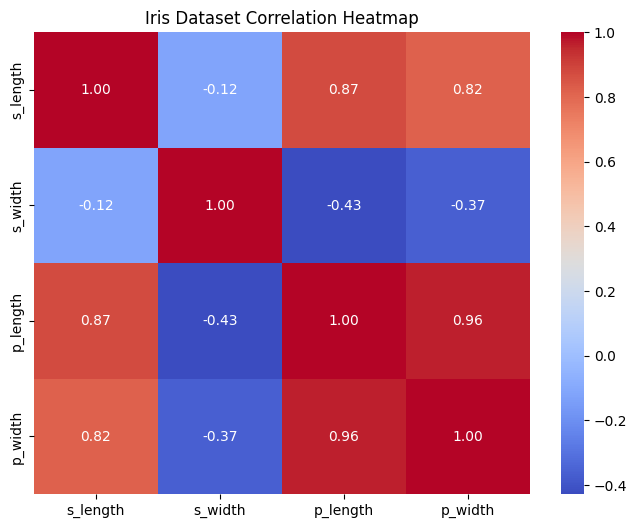

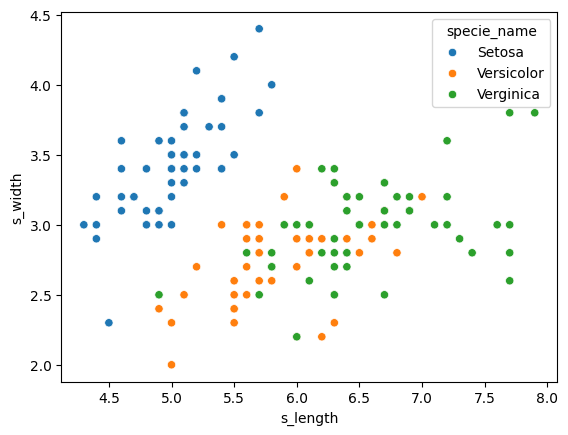

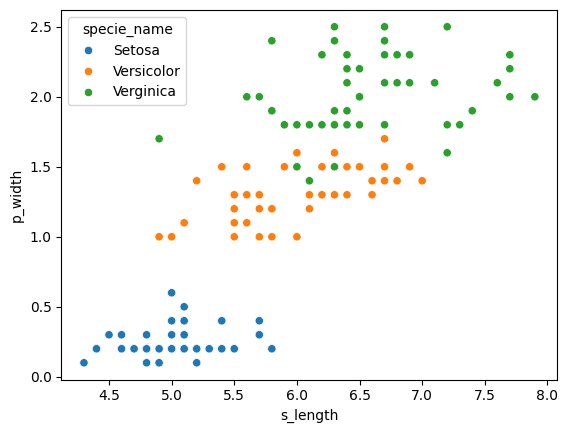

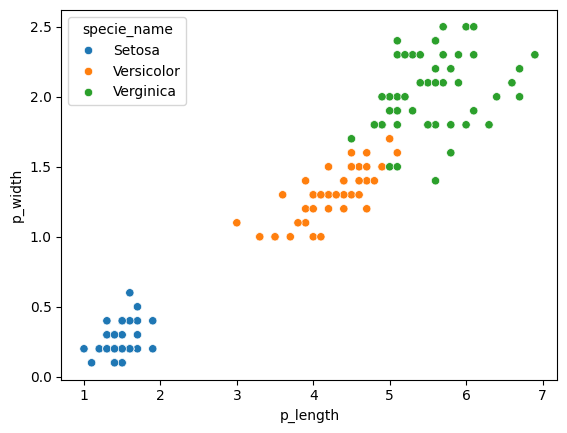

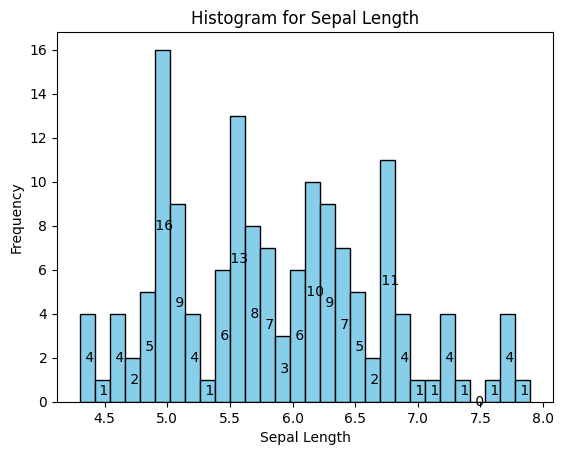

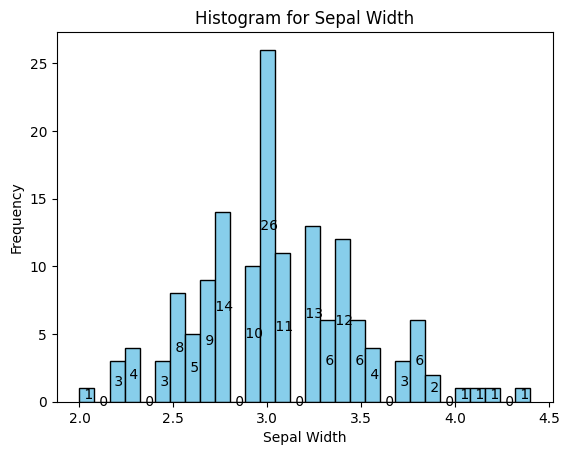

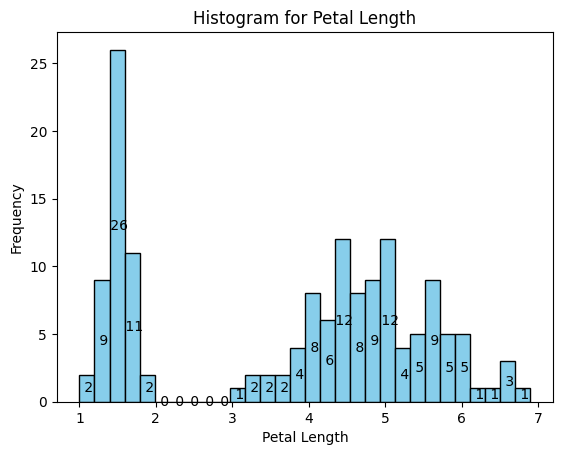

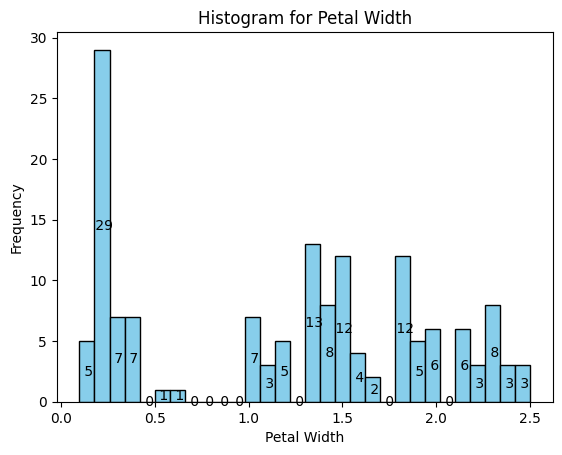

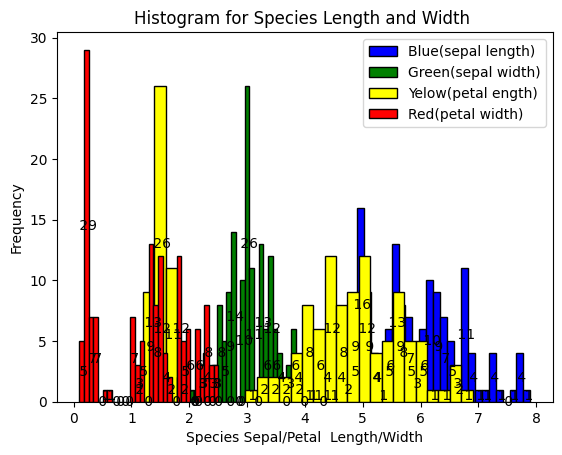


1.3 split_dataset()
Spliting the dataset using test size=0.2
Checking the split datasets
Split datasets are ok

1.4 scale_feature_data()
Not required for this datasets


2.0 choose_and_train_mode()

3.0 make_predictions_and_check_results()
Test Features Data
[[6.1 2.8 4.7 1.2]
 [5.7 3.8 1.7 0.3]
 [7.7 2.6 6.9 2.3]
 [6.  2.9 4.5 1.5]
 [6.8 2.8 4.8 1.4]
 [5.4 3.4 1.5 0.4]
 [5.6 2.9 3.6 1.3]
 [6.9 3.1 5.1 2.3]
 [6.2 2.2 4.5 1.5]
 [5.8 2.7 3.9 1.2]
 [6.5 3.2 5.1 2. ]
 [4.8 3.  1.4 0.1]
 [5.5 3.5 1.3 0.2]
 [4.9 3.1 1.5 0.1]
 [5.1 3.8 1.5 0.3]
 [6.3 3.3 4.7 1.6]
 [6.5 3.  5.8 2.2]
 [5.6 2.5 3.9 1.1]
 [5.7 2.8 4.5 1.3]
 [6.4 2.8 5.6 2.2]
 [4.7 3.2 1.6 0.2]
 [6.1 3.  4.9 1.8]
 [5.  3.4 1.6 0.4]
 [6.4 2.8 5.6 2.1]
 [7.9 3.8 6.4 2. ]
 [6.7 3.  5.2 2.3]
 [6.7 2.5 5.8 1.8]
 [6.8 3.2 5.9 2.3]
 [4.8 3.  1.4 0.3]
 [4.8 3.1 1.6 0.2]]

Test Target Data
     0
73   1
18   0
118  2
78   1
76   1
31   0
64   1
141  2
68   1
82   1
110  2
12   0
36   0
9    0
19   0
56   1
104  2
69   1
55   1
132  2
29  

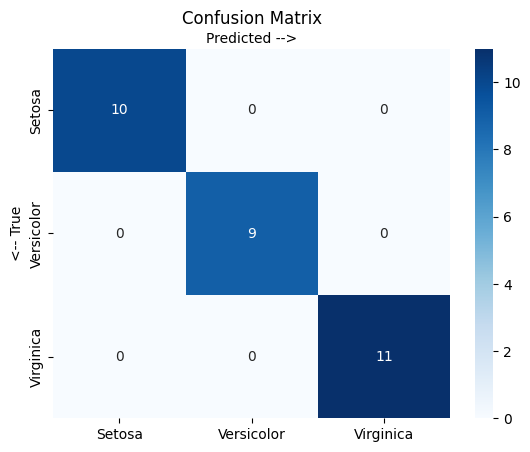


Saving the confusion metrix  in  confusion_matr\ix.png
Successfully saved the file

4.4 create_advanved_metrics()

4.5 Plot Decision Tree


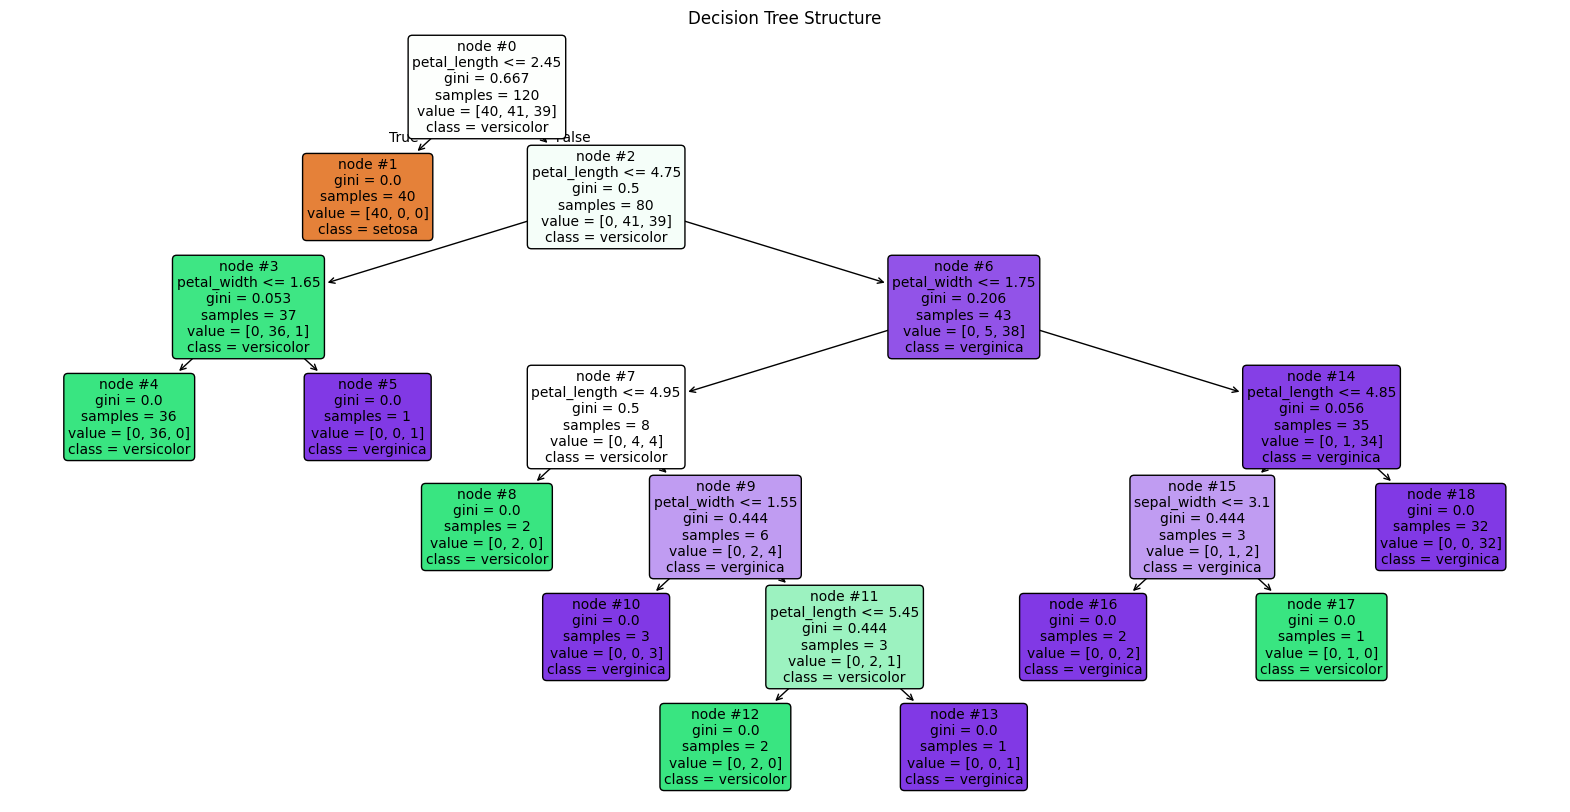


4.6 interpret_the_model()

Sample Details
No of feature samples = 150
No of target samples   = 150
No of feature samples  for training = 120
No of feature samples  for testing  = 30
No of  target  samples for training  = 120
No of target samples for testing     = 30 


Heatmap Observations
1. Corelation between sepal length and petal length is 0.87
2. Correlation between sepal length and petal width is 0.82
3. Correlation between petal length and petal width is 0.96

Scatter Plot Observations
Sepal Width vs Sepal Length
1. Species Setosa has smaller sepal lengths but larger sepal widths.
2. Versicolor Species lies in the middle of the other two species in terms of sepal length and width
3. Species Virginica has larger sepal lengths but smaller sepal widths

Petal Width vs Sepal Length
1. Species Setosa has smaller sepal lengths but larger sepal widths.
2. Versicolor Species lies in the middle of the other two species in terms of sepal length and width
3. Species Virginica has larger s

In [21]:
if   __name__   ==  "__main__" :
     main()